<a href="https://colab.research.google.com/github/Faisaleka21/Machine_Learning/blob/main/Pengelompokkan%20Tingkat%20Konsumsi%20dging%20Kambing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
# ======================================================================
# 1. INISIALISASI LIBRARY
# ======================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

In [82]:
# ======================================================================
# 2. LOAD DATASET DARI FILE CSV
# ======================================================================
# Ganti 'nama_file.csv' dengan path file CSV Anda
# Contoh: df = pd.read_csv('sheep_consumption.csv')
# Atau jika file berada di folder yang sama: df = pd.read_csv('data_sheep.csv')

print("="*60)
print("PROGRAM CLUSTERING KONSUMSI DAGING DOMBA (SHEEP)")
print("="*60)

# Baca dataset CSV
file_path = 'https://raw.githubusercontent.com/Faisaleka21/Machine_Learning/refs/heads/main/data_set/world_meat_consumpiton_trends.csv'  # <-- GANTI dengan nama file CSV Anda
try:
    df = pd.read_csv(file_path)
    print(f"\nDataset berhasil dimuat dari: {file_path}")
    print(f"Jumlah baris: {len(df)}")
    print(f"Jumlah kolom: {len(df.columns)}")
except FileNotFoundError:
    print(f"\nERROR: File '{file_path}' tidak ditemukan!")
    print("Pastikan file CSV berada di direktori yang benar.")
    print("Program akan dihentikan.")
    exit()

    # Tampilkan beberapa baris pertama
print("\n5 Baris Pertama Dataset:")
print(df.head())

# Tampilkan informasi dataset
print("\nInformasi Dataset:")
print(df.info())

# Tampilkan nama kolom
print("\nNama Kolom dalam Dataset:")
print(df.columns.tolist())

PROGRAM CLUSTERING KONSUMSI DAGING DOMBA (SHEEP)

Dataset berhasil dimuat dari: https://raw.githubusercontent.com/Faisaleka21/Machine_Learning/refs/heads/main/data_set/world_meat_consumpiton_trends.csv
Jumlah baris: 12140
Jumlah kolom: 8

5 Baris Pertama Dataset:
  LOCATION    INDICATOR SUBJECT MEASURE FREQUENCY  TIME      Value  Flag Codes
0      AUS  MEATCONSUMP    BEEF  KG_CAP         A  1990   0.000004         NaN
1      AUS  MEATCONSUMP    BEEF  KG_CAP         A  1991  27.808401         NaN
2      AUS  MEATCONSUMP    BEEF  KG_CAP         A  1992  26.278166         NaN
3      AUS  MEATCONSUMP    BEEF  KG_CAP         A  1993  26.244478         NaN
4      AUS  MEATCONSUMP    BEEF  KG_CAP         A  1994  25.541244         NaN

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12140 entries, 0 to 12139
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   LOCATION    12140 non-null  object 
 1   INDICA

In [83]:
# ======================================================================
# 3. FILTER DATA DENGAN SUBJECT = SHEEP
# ======================================================================
print("\n" + "="*60)
print("FILTER DATA: SUBJECT = SHEEP")
print("="*60)

# Periksa apakah kolom SUBJECT ada
if 'SUBJECT' not in df.columns:
    print("ERROR: Kolom 'SUBJECT' tidak ditemukan dalam dataset!")
    print("Kolom yang tersedia:", df.columns.tolist())
    exit()

# Tampilkan nilai unik SUBJECT sebelum filter
print(f"\nNilai unik SUBJECT sebelum filter: {df['SUBJECT'].unique()}")

# Filter data
df_sheep = df[df['SUBJECT'] == 'SHEEP'].copy()
print(f"\nJumlah data setelah filter SHEEP: {len(df_sheep)}")

# Jika tidak ada data SHEEP
if len(df_sheep) == 0:
    print("ERROR: Tidak ada data dengan SUBJECT = 'SHEEP'!")
    exit()


FILTER DATA: SUBJECT = SHEEP

Nilai unik SUBJECT sebelum filter: ['BEEF' 'PIG' 'POULTRY' 'SHEEP']

Jumlah data setelah filter SHEEP: 3035


In [84]:
# ======================================================================
# 4. PREPROCESSING: MENGHAPUS MISSING VALUE DAN IDENTITAS NEGARA
# ======================================================================
print("\n" + "="*60)
print("PREPROCESSING DATA")
print("="*60)

# Cek missing value
print("\nJumlah missing value per kolom:")
missing_values = df_sheep.isnull().sum()
print(missing_values[missing_values > 0] if sum(missing_values) > 0 else "Tidak ada missing value")

# Hapus kolom Flag Codes karena seluruhnya kosong dan tidak digunakan
if 'Flag Codes' in df_sheep.columns:
    df_sheep = df_sheep.drop(columns=['Flag Codes'])

# Hapus missing value hanya pada kolom penting
initial_rows = len(df_sheep)
df_sheep = df_sheep.dropna(subset=['LOCATION', 'TIME', 'Value'])
rows_removed = initial_rows - len(df_sheep)

print(f"\nBaris yang dihapus karena missing value: {rows_removed}")

# Pastikan kolom LOCATION dan Value ada
if 'LOCATION' not in df_sheep.columns:
    print("ERROR: Kolom 'LOCATION' tidak ditemukan!")
    exit()
if 'Value' not in df_sheep.columns:
    print("ERROR: Kolom 'Value' tidak ditemukan!")
    exit()

# Mengubah LOCATION menjadi identitas negara (tidak perlu encoding khusus)
print(f"\nJumlah negara unik: {df_sheep['LOCATION'].nunique()}")
print(f"Daftar negara: {sorted(df_sheep['LOCATION'].unique())}")



PREPROCESSING DATA

Jumlah missing value per kolom:
Flag Codes    3035
dtype: int64

Baris yang dihapus karena missing value: 0

Jumlah negara unik: 39
Daftar negara: ['ARG', 'AUS', 'BRA', 'BRICS', 'CAN', 'CHE', 'CHL', 'CHN', 'COL', 'EGY', 'ETH', 'EU27', 'GBR', 'IDN', 'IND', 'IRN', 'ISR', 'JPN', 'KAZ', 'KOR', 'MEX', 'MYS', 'NGA', 'NOR', 'NZL', 'OECD', 'PAK', 'PER', 'PHL', 'PRY', 'RUS', 'SAU', 'THA', 'TUR', 'UKR', 'USA', 'VNM', 'WLD', 'ZAF']


In [85]:
# ======================================================================
# 5. BENTUK DATASET PER NEGARA (RATA-RATA KONSUMSI)
# ======================================================================
print("\n" + "="*60)
print("AGREGASI DATA PER NEGARA")
print("="*60)

# Menghitung rata-rata konsumsi sheep per negara
df_country = df_sheep.groupby('LOCATION')['Value'].mean().reset_index()
df_country.columns = ['Country', 'Avg_Consumption']

print(f"\nJumlah negara setelah agregasi: {len(df_country)}")
print("\n5 Negara Pertama (rata-rata konsumsi):")
print(df_country.head())

print("\nStatistik Deskriptif Rata-rata Konsumsi:")
print(df_country['Avg_Consumption'].describe())

# Cek apakah cukup data untuk clustering
if len(df_country) < 3:
    print(f"\nERROR: Hanya ada {len(df_country)} negara, minimal 3 negara untuk clustering!")
    exit()


AGREGASI DATA PER NEGARA

Jumlah negara setelah agregasi: 39

5 Negara Pertama (rata-rata konsumsi):
  Country  Avg_Consumption
0     ARG        28.788622
1     AUS       140.178051
2     BRA        60.923994
3   BRICS      2471.656163
4     CAN        17.531990

Statistik Deskriptif Rata-rata Konsumsi:
count      39.000000
mean      368.059476
std      1101.362581
min         1.269450
25%        14.811942
50%        58.933267
75%       160.575482
max      6351.286491
Name: Avg_Consumption, dtype: float64


In [86]:
# ======================================================================
# 6. NORMALISASI MENGGUNAKAN MINMAXSCALER
# ======================================================================
print("\n" + "="*60)
print("NORMALISASI DATA")
print("="*60)

# Ambil atribut rata-rata konsumsi sebagai variabel clustering
X = df_country[['Avg_Consumption']].values

# Normalisasi dengan MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nNilai minimum setelah normalisasi: {X_scaled.min():.4f}")
print(f"Nilai maksimum setelah normalisasi: {X_scaled.max():.4f}")
print(f"Rentang nilai: [{X_scaled.min():.4f}, {X_scaled.max():.4f}]")



NORMALISASI DATA

Nilai minimum setelah normalisasi: 0.0000
Nilai maksimum setelah normalisasi: 1.0000
Rentang nilai: [0.0000, 1.0000]


In [87]:
# ======================================================================
# 7. MENENTUKAN JUMLAH CLUSTER TERBAIK DENGAN ELBOW METHOD
# ======================================================================
print("\n" + "="*60)
print("ELBOW METHOD: MENCARI k OPTIMAL")
print("="*60)

inertia = []
K_range = range(2, min(11, len(df_country)))  # Maksimal k=10 atau sesuai jumlah data

print("\nNilai Inertia untuk setiap k:")
print("-" * 30)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    print(f"k = {k}: Inertia = {inertia[-1]:.4f}")

# Tentukan k optimal
if len(K_range) >= 3:
    # Metode selisih untuk mencari elbow
    inertia_diff = np.diff(inertia)
    inertia_diff2 = np.diff(inertia_diff)
    optimal_k_idx = np.argmax(np.abs(inertia_diff2)) + 1
    optimal_k = list(K_range)[optimal_k_idx + 1]
else:
    # Jika range terbatas, pilih k tengah
    optimal_k = list(K_range)[len(K_range)//2]

print(f"\nJumlah cluster optimal berdasarkan Elbow Method: k = {optimal_k}")


ELBOW METHOD: MENCARI k OPTIMAL

Nilai Inertia untuk setiap k:
------------------------------
k = 2: Inertia = 0.2320
k = 3: Inertia = 0.0313
k = 4: Inertia = 0.0115
k = 5: Inertia = 0.0063
k = 6: Inertia = 0.0018
k = 7: Inertia = 0.0009
k = 8: Inertia = 0.0003
k = 9: Inertia = 0.0002
k = 10: Inertia = 0.0001

Jumlah cluster optimal berdasarkan Elbow Method: k = 4


In [88]:
# ======================================================================
# 8. CLUSTERING MENGGUNAKAN K-MEANS
# ======================================================================
print("\n" + "="*60)
print(f"CLUSTERING K-MEANS DENGAN k = {optimal_k}")
print("="*60)

# Lakukan clustering
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_country['Cluster'] = kmeans_optimal.fit_predict(X_scaled)

print("\nClustering selesai dilakukan!")


CLUSTERING K-MEANS DENGAN k = 4

Clustering selesai dilakukan!


In [89]:
# ======================================================================
# 9. EVALUASI HASIL CLUSTERING
# ======================================================================
print("\n" + "="*60)
print("EVALUASI HASIL CLUSTERING")
print("="*60)

# Silhouette Score
sil_score = silhouette_score(X_scaled, df_country['Cluster'])
print(f"\nSilhouette Score: {sil_score:.4f}")
if sil_score > 0.7:
    print("→ Interpretasi: Struktur cluster sangat kuat")
elif sil_score > 0.5:
    print("→ Interpretasi: Struktur cluster cukup baik")
elif sil_score > 0.25:
    print("→ Interpretasi: Struktur cluster lemah")
else:
    print("→ Interpretasi: Struktur cluster tidak jelas (mungkin overlap)")

# Davies-Bouldin Index (DBI)
dbi_score = davies_bouldin_score(X_scaled, df_country['Cluster'])
print(f"\nDavies-Bouldin Index (DBI): {dbi_score:.4f}")
if dbi_score < 0.5:
    print("→ Interpretasi: Separasi antar cluster sangat baik")
elif dbi_score < 1.0:
    print("→ Interpretasi: Separasi antar cluster cukup baik")
else:
    print("→ Interpretasi: Separasi antar cluster kurang baik")


EVALUASI HASIL CLUSTERING

Silhouette Score: 0.8223
→ Interpretasi: Struktur cluster sangat kuat

Davies-Bouldin Index (DBI): 0.1906
→ Interpretasi: Separasi antar cluster sangat baik


In [90]:
# ======================================================================
# 10. TAMPILKAN INFORMASI CLUSTER
# ======================================================================
print("\n" + "="*60)
print("INFORMASI HASIL CLUSTERING")
print("="*60)

# Jumlah anggota tiap cluster
cluster_counts = df_country['Cluster'].value_counts().sort_index()
print("\n1. Jumlah Anggota per Cluster:")
print("-" * 30)
for cluster_id in range(optimal_k):
    count = cluster_counts.get(cluster_id, 0)
    print(f"Cluster {cluster_id}: {count} negara")

# Centroid cluster
print("\n2. Centroid Cluster:")
print("-" * 30)
centroids_scaled = kmeans_optimal.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

for i in range(optimal_k):
    print(f"Cluster {i}:")
    print(f"   - Nilai normalisasi: {centroids_scaled[i][0]:.4f}")
    print(f"   - Nilai asli (kg/capita): {centroids_original[i][0]:.4f}")

# Detail anggota setiap cluster
print("\n3. Anggota Setiap Cluster:")
print("-" * 30)
for cluster_id in sorted(df_country['Cluster'].unique()):
    cluster_data = df_country[df_country['Cluster'] == cluster_id]
    print(f"\nCluster {cluster_id} ({len(cluster_data)} negara):")
    print(f"Range konsumsi: {cluster_data['Avg_Consumption'].min():.2f} - {cluster_data['Avg_Consumption'].max():.2f} kg/capita")
    print("Negara anggota:")
    for _, row in cluster_data.iterrows():
        print(f"   • {row['Country']}: {row['Avg_Consumption']:.4f} kg/capita")


INFORMASI HASIL CLUSTERING

1. Jumlah Anggota per Cluster:
------------------------------
Cluster 0: 35 negara
Cluster 1: 1 negara
Cluster 2: 2 negara
Cluster 3: 1 negara

2. Centroid Cluster:
------------------------------
Cluster 0:
   - Nilai normalisasi: 0.0119
   - Nilai asli (kg/capita): 76.6910
Cluster 1:
   - Nilai normalisasi: 1.0000
   - Nilai asli (kg/capita): 6351.2865
Cluster 2:
   - Nilai normalisasi: 0.3412
   - Nilai asli (kg/capita): 2168.1640
Cluster 3:
   - Nilai normalisasi: 0.1545
   - Nilai asli (kg/capita): 982.5214

3. Anggota Setiap Cluster:
------------------------------

Cluster 0 (35 negara):
Range konsumsi: 1.27 - 356.37 kg/capita
Negara anggota:
   • ARG: 28.7886 kg/capita
   • AUS: 140.1781 kg/capita
   • BRA: 60.9240 kg/capita
   • CAN: 17.5320 kg/capita
   • CHE: 6.8270 kg/capita
   • CHL: 5.5285 kg/capita
   • COL: 5.3100 kg/capita
   • EGY: 62.1514 kg/capita
   • ETH: 40.8148 kg/capita
   • EU27: 313.3987 kg/capita
   • GBR: 125.8763 kg/capita
   • I


MEMBUAT VISUALISASI...


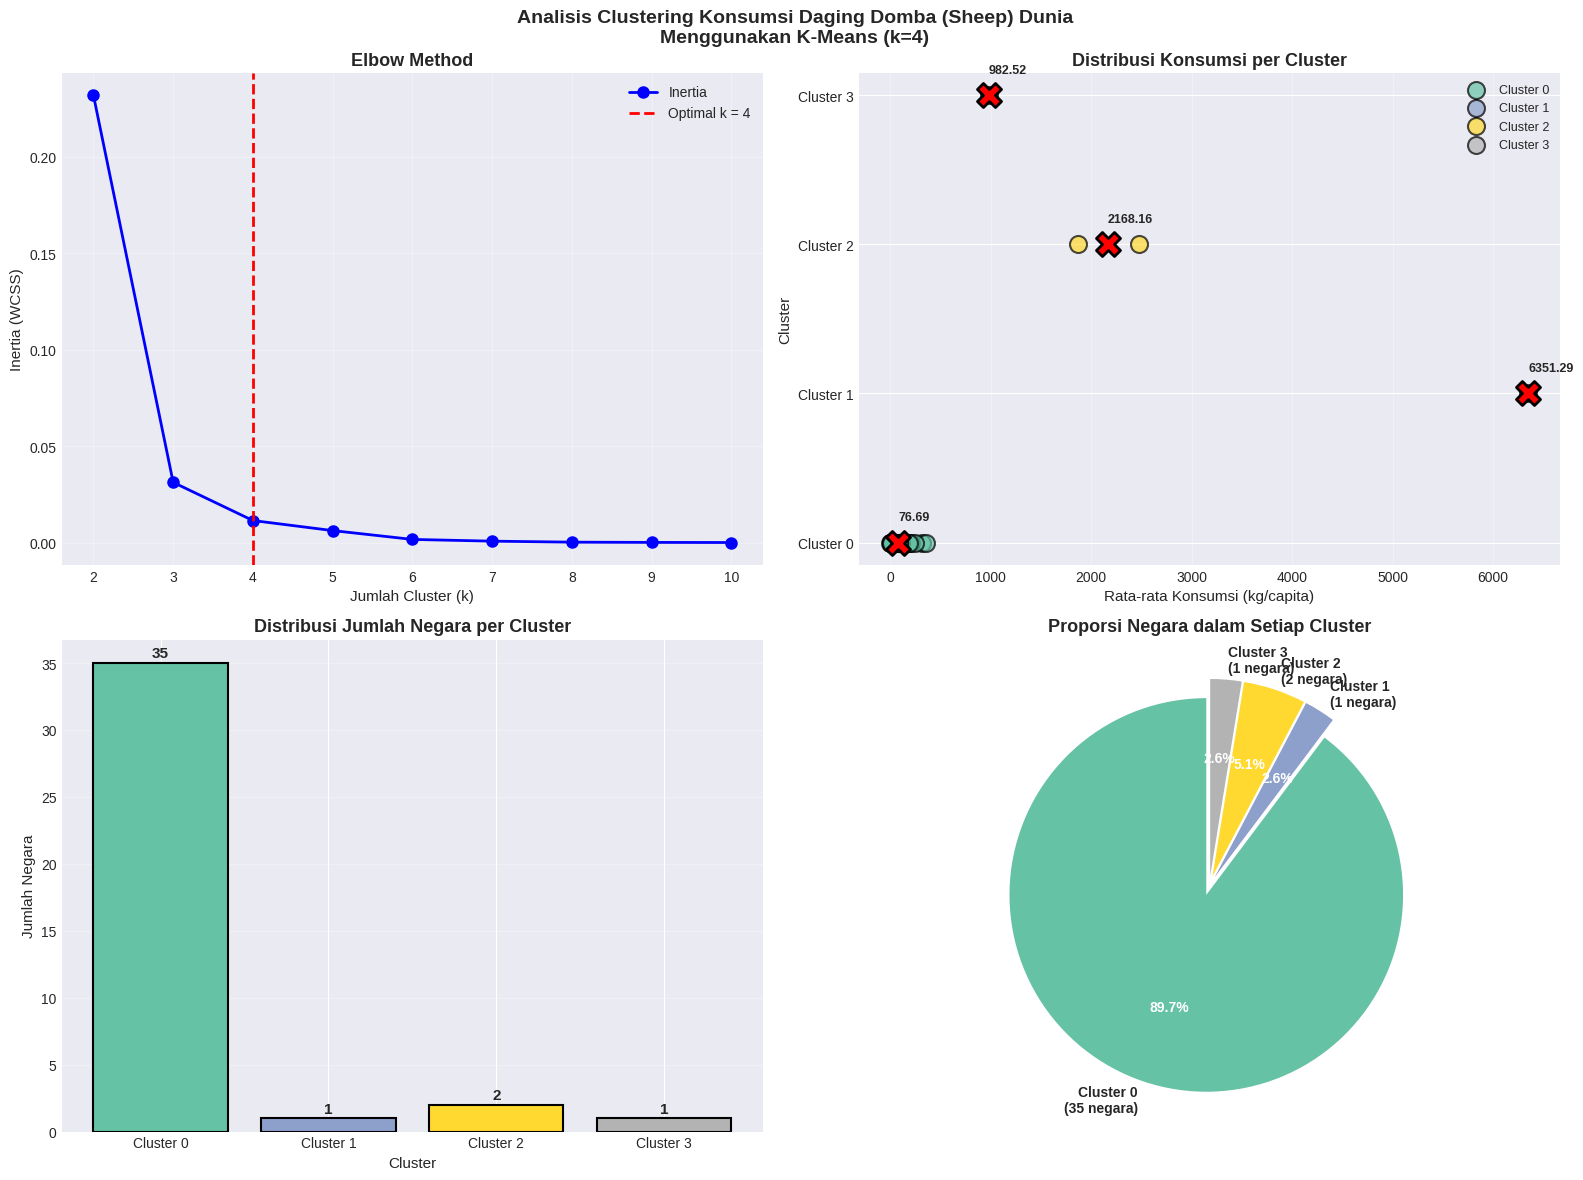

In [91]:
# ======================================================================
# 11. VISUALISASI
# ======================================================================
print("\n" + "="*60)
print("MEMBUAT VISUALISASI...")
print("="*60)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Buat figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisis Clustering Konsumsi Daging Domba (Sheep) Dunia\n'
             f'Menggunakan K-Means (k={optimal_k})',
             fontsize=14, fontweight='bold')

# --- 11a. Elbow Method Plot ---
ax1 = axes[0, 0]
ax1.plot(list(K_range), inertia, 'bo-', linewidth=2, markersize=8, label='Inertia')
ax1.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2,
            label=f'Optimal k = {optimal_k}')
ax1.set_xlabel('Jumlah Cluster (k)', fontsize=11)
ax1.set_ylabel('Inertia (WCSS)', fontsize=11)
ax1.set_title('Elbow Method', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(list(K_range))

# --- 11b. Scatter Plot Hasil Clustering ---
ax2 = axes[0, 1]
colors = plt.cm.Set2(np.linspace(0, 1, optimal_k))

# Plot setiap cluster
for cluster_id in range(optimal_k):
    cluster_data = df_country[df_country['Cluster'] == cluster_id]
    if len(cluster_data) > 0:
        ax2.scatter(cluster_data['Avg_Consumption'],
                   [cluster_id] * len(cluster_data),
                   c=[colors[cluster_id]],
                   s=150,
                   alpha=0.7,
                   edgecolors='black',
                   linewidth=1.5,
                   label=f'Cluster {cluster_id}',
                   zorder=2)

# Plot centroid
for i in range(optimal_k):
    ax2.scatter(centroids_original[i][0], i,
               c='red', marker='X', s=300,
               edgecolors='black', linewidth=2,
               zorder=3)
    ax2.text(centroids_original[i][0] + 0.02, i + 0.15,
            f'{centroids_original[i][0]:.2f}',
            fontsize=9, fontweight='bold')

ax2.set_xlabel('Rata-rata Konsumsi (kg/capita)', fontsize=11)
ax2.set_ylabel('Cluster', fontsize=11)
ax2.set_title('Distribusi Konsumsi per Cluster', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='x')
ax2.set_yticks(range(optimal_k))
ax2.set_yticklabels([f'Cluster {i}' for i in range(optimal_k)])

# --- 11c. Bar Chart Jumlah Negara per Cluster ---
ax3 = axes[1, 0]
bars = ax3.bar(range(optimal_k),
               [cluster_counts.get(i, 0) for i in range(optimal_k)],
               color=colors,
               edgecolor='black',
               linewidth=1.5)

# Tambahkan label di atas bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    if height > 0:
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax3.set_xlabel('Cluster', fontsize=11)
ax3.set_ylabel('Jumlah Negara', fontsize=11)
ax3.set_title('Distribusi Jumlah Negara per Cluster', fontsize=13, fontweight='bold')
ax3.set_xticks(range(optimal_k))
ax3.set_xticklabels([f'Cluster {i}' for i in range(optimal_k)])
ax3.grid(True, alpha=0.3, axis='y')

# --- 11d. Pie Chart Proporsi Cluster ---
ax4 = axes[1, 1]
sizes = [cluster_counts.get(i, 0) for i in range(optimal_k)]
if sum(sizes) > 0:  # Pastikan ada data
    wedges, texts, autotexts = ax4.pie(sizes,
                                        labels=[f'Cluster {i}\n({sizes[i]} negara)' for i in range(optimal_k)],
                                        autopct='%1.1f%%',
                                        colors=colors,
                                        startangle=90,
                                        explode=[0.05] * optimal_k)
    for text in texts:
        text.set_fontsize(10)
        text.set_fontweight('bold')
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')

ax4.set_title('Proporsi Negara dalam Setiap Cluster', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [92]:
# ======================================================================
# 12. INTERPRETASI HASIL CLUSTER
# ======================================================================
print("\n" + "="*60)
print("INTERPRETASI HASIL CLUSTER")
print("="*60)

# Urutkan cluster berdasarkan centroid (dari terendah ke tertinggi)
centroids_list = [(i, centroids_original[i][0]) for i in range(optimal_k)]
centroids_list.sort(key=lambda x: x[1])

print("\nKlasifikasi Cluster berdasarkan Tingkat Konsumsi:")
print("-" * 50)

# Tentukan label untuk setiap cluster
cluster_labels = {}
for rank, (cluster_id, centroid_val) in enumerate(centroids_list):
    # Tentukan kategori berdasarkan posisi
    if optimal_k == 2:
        if rank == 0:
            category = "RENDAH"
        else:
            category = "TINGGI"
    elif optimal_k == 3:
        if rank == 0:
            category = "RENDAH"
        elif rank == 1:
            category = "SEDANG"
        else:
            category = "TINGGI"
    else:
        # Untuk k > 3
        if rank == 0:
            category = "SANGAT RENDAH"
        elif rank == optimal_k - 1:
            category = "SANGAT TINGGI"
        elif rank <= optimal_k // 3:
            category = "RENDAH"
        elif rank <= 2 * optimal_k // 3:
            category = "SEDANG"
        else:
            category = "TINGGI"

    cluster_labels[cluster_id] = category

    # Tampilkan detail cluster
    cluster_data = df_country[df_country['Cluster'] == cluster_id]
    countries = cluster_data['Country'].tolist()

    print(f"\n{'='*40}")
    print(f"CLUSTER {cluster_id} - KONSUMSI {category}")
    print(f"{'='*40}")
    print(f"Centroid: {centroid_val:.4f} kg/capita")
    print(f"Jumlah Negara: {len(countries)}")
    print(f"Range Konsumsi: {cluster_data['Avg_Consumption'].min():.4f} - "
          f"{cluster_data['Avg_Consumption'].max():.4f} kg/capita")
    print(f"Karakteristik: Kelompok negara dengan tingkat konsumsi daging domba {category.lower()}")
    print(f"Negara Anggota:")
    for country in sorted(countries):
        avg_val = cluster_data[cluster_data['Country'] == country]['Avg_Consumption'].values[0]
        print(f"  • {country}: {avg_val:.4f} kg/capita")

# Kesimpulan
print("\n" + "="*60)
print("KESIMPULAN ANALISIS")
print("="*60)
print(f"""
Berdasarkan hasil clustering K-Means dengan k={optimal_k} cluster:

1. Metrik Evaluasi:
   • Silhouette Score: {sil_score:.4f}
   • Davies-Bouldin Index: {dbi_score:.4f}

2. Komposisi Cluster:""")

for cluster_id, category in cluster_labels.items():
    count = len(df_country[df_country['Cluster'] == cluster_id])
    centroid = centroids_original[cluster_id][0]
    print(f"   • Cluster {cluster_id} ({category}): {count} negara, centroid = {centroid:.4f} kg/capita")

print(f"""
3. Interpretasi Bisnis:
   • Cluster konsumsi tinggi: Potensi pasar utama untuk produk daging domba
   • Cluster konsumsi sedang: Peluang pengembangan pasar dengan strategi yang tepat
   • Cluster konsumsi rendah: Tantangan penetrasi pasar, perlu edukasi konsumen

4. Rekomendasi:
   • Fokus ekspor ke negara-negara dengan konsumsi tinggi
   • Kembangkan program promosi di negara konsumsi sedang
   • Lakukan riset pasar lebih lanjut untuk negara konsumsi rendah
""")


INTERPRETASI HASIL CLUSTER

Klasifikasi Cluster berdasarkan Tingkat Konsumsi:
--------------------------------------------------

CLUSTER 0 - KONSUMSI SANGAT RENDAH
Centroid: 76.6910 kg/capita
Jumlah Negara: 35
Range Konsumsi: 1.2695 - 356.3729 kg/capita
Karakteristik: Kelompok negara dengan tingkat konsumsi daging domba sangat rendah
Negara Anggota:
  • ARG: 28.7886 kg/capita
  • AUS: 140.1781 kg/capita
  • BRA: 60.9240 kg/capita
  • CAN: 17.5320 kg/capita
  • CHE: 6.8270 kg/capita
  • CHL: 5.5285 kg/capita
  • COL: 5.3100 kg/capita
  • EGY: 62.1514 kg/capita
  • ETH: 40.8148 kg/capita
  • EU27: 313.3987 kg/capita
  • GBR: 125.8763 kg/capita
  • IDN: 58.9333 kg/capita
  • IND: 356.3729 kg/capita
  • IRN: 201.8514 kg/capita
  • ISR: 6.9467 kg/capita
  • JPN: 22.1435 kg/capita
  • KAZ: 89.2497 kg/capita
  • KOR: 5.8329 kg/capita
  • MEX: 38.1130 kg/capita
  • MYS: 13.9513 kg/capita
  • NGA: 180.9729 kg/capita
  • NOR: 15.6726 kg/capita
  • NZL: 39.3004 kg/capita
  • PAK: 244.1518 kg/ca

In [93]:
# # ======================================================================
# # SIMPAN HASIL KE FILE
# # ======================================================================
# output_file = 'hasil_clustering_konsumsi_sheep.csv'
# df_country.to_csv(output_file, index=False)
# print(f"\nHasil clustering telah disimpan ke: {output_file}")
# print("\nProgram selesai dijalankan!")